In [36]:
import os
import re
import json
import random
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from concurrent.futures.process import BrokenProcessPool
from pydantic import BaseModel
from typing import Any, Optional, Self
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset, Dataset, DatasetDict
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd


load_dotenv(override=True)


True

In [2]:
class Item(BaseModel):
    """
    An Item is a data-point of a Product with a Price
    """

    title: str
    category: str
    price: float
    full: Optional[str] = None
    weight: Optional[float] = None
    summary: Optional[str] = None
    prompt: Optional[str] = None
    id: Optional[int] = None

    def make_prompt(self, text: str):
        self.prompt = f"{QUESTION}\n\n{text}\n\n{PREFIX}{round(self.price)}.00"

    def test_prompt(self) -> str:
        return self.prompt.split(PREFIX)[0] + PREFIX

    def __repr__(self) -> str:
        return f"<{self.title} = ${self.price}>"

    @staticmethod
    def push_to_hub(dataset_name: str, train: list[Self], val: list[Self], test: list[Self]):
        """Push Item lists to HuggingFace Hub"""
        DatasetDict(
            {
                "train": Dataset.from_list([item.model_dump() for item in train]),
                "validation": Dataset.from_list([item.model_dump() for item in val]),
                "test": Dataset.from_list([item.model_dump() for item in test]),
            }
        ).push_to_hub(dataset_name)

    @classmethod
    def from_hub(cls, dataset_name: str) -> tuple[list[Self], list[Self], list[Self]]:
        """Load from HuggingFace Hub and reconstruct Items"""
        ds = load_dataset(dataset_name)
        return (
            [cls.model_validate(row) for row in ds["train"]],
            [cls.model_validate(row) for row in ds["validation"]],
            [cls.model_validate(row) for row in ds["test"]],
        )


In [3]:
from huggingface_hub import HfApi

hf_token = os.getenv("hf_token") or os.getenv("HF_TOKEN")
if not hf_token:
    raise ValueError("Missing HF token. Set hf_token or HF_TOKEN in your environment/.env")

# Ensure the active env token matches what we loaded.
os.environ["HF_TOKEN"] = hf_token
login(hf_token, add_to_git_credential=True)

me = HfApi(token=hf_token).whoami()
fine_grained = ((me.get("auth") or {}).get("accessToken") or {}).get("fineGrained") or {}
perms = list(fine_grained.get("global", []))
for scope in fine_grained.get("scoped", []):
    perms.extend(scope.get("permissions", []))
if not any("write" in str(p).lower() for p in perms):
    raise PermissionError(
        "HF token lacks write permission for dataset creation. Create a token with Write access and update .env."
    )


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## Loading the HF dataset

In [4]:
from datasets import load_dataset

dataset = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_meta_Appliances",
    split="full",
    trust_remote_code=True,
)


In [5]:
# Investigate a particular datapoint

dataset[6]

{'main_category': 'Appliances',
 'title': 'WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003',
 'average_rating': 4.6,
 'rating_number': 323,
 'features': ['【PARTS NUMBER】The WD12X10327 dishwasher top rack wheels and stud assembly Kit （4 pcs）',
  '【SCOPE OF APPLICATION】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud',
  '【REPLACES PART】1811003, AP4980629, WD12X0330, WD12X0356, WD12X0357, WD12X0383, WD12X0385, WD12X10327, WD12X330, WD12X356, WD12X357, WD12X383, WD12X385',
  '【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure',
  '【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask

In [6]:
print(f"Number of Appliances: {len(dataset):,}")

Number of Appliances: 94,327


In [7]:

# What's the most expensive item?

max_price = 0
max_item = None

for datapoint in tqdm(dataset):
    try:
        price = float(datapoint["price"])
        if price > max_price:
            max_item = datapoint
            max_price = price
    except ValueError:
        pass

print(f"The most expensive item is {max_item['title']} and it costs {max_price:,.2f}")

  0%|          | 0/94327 [00:00<?, ?it/s]

The most expensive item is TurboChef BULLET Rapid Cook Electric Microwave Convection Oven and it costs 21,095.62


In [8]:
MIN_CHARS = 600
MIN_PRICE = 0.5
MAX_PRICE = 999.49
MAX_TEXT_EACH = 3000
MAX_TEXT_TOTAL = 4000

REMOVALS = [
    "Part Number",
    "Best Sellers Rank",
    "Batteries Included?",
    "Batteries Required?",
    "Item model number",
]


def simplify(text_list) -> str:
    """
    Return a simplified string without too much whitespace and limited to MAX_TEXT characters
    """
    return (
        str(text_list)
        .replace("\n", " ")
        .replace("\r", "")
        .replace("\t", "")
        .replace("  ", " ")
        .strip()[:MAX_TEXT_EACH]
    )


def scrub(title, description, features, details) -> str:
    """
    Return a cleansed full string with product numbers and unimportant details removed
    """
    for remove in REMOVALS:
        details.pop(remove, None)
    result = title + "\n"
    if description:
        result += simplify(description) + "\n"
    if features:
        result += simplify(features) + "\n"
    if details:
        result += json.dumps(details) + "\n"
    pattern = r"\b(?=[A-Z0-9]{7,}\b)(?=.*[A-Z])(?=.*\d)[A-Z0-9]+\b"
    return re.sub(pattern, "", result).strip()[:MAX_TEXT_TOTAL]


def get_weight(details):
    weight_str = details.get("Item Weight")
    if weight_str:
        parts = weight_str.split(" ")
        amount = float(parts[0])
        unit = parts[1].lower()
        if unit == "pounds":
            return amount
        elif unit == "ounces":
            return amount / 16
        elif unit == "grams":
            return amount / 453.592
        elif unit == "milligrams":
            return amount / 453592
        elif unit == "kilograms":
            return amount / 0.453592
        elif unit == "hundredths" and parts[2].lower() == "pounds":
            return amount / 100
    return 0


def parse(datapoint, category):
    try:
        price = float(datapoint["price"])
    except (TypeError, ValueError):
        return None

    if not (MIN_PRICE <= price <= MAX_PRICE):
        return None

    title = datapoint.get("title", "")
    description = datapoint.get("description", "")
    features = datapoint.get("features", [])

    raw_details = datapoint.get("details", {})
    if isinstance(raw_details, str):
        try:
            details = json.loads(raw_details)
        except json.JSONDecodeError:
            details = {}
    elif isinstance(raw_details, dict):
        details = dict(raw_details)
    else:
        details = {}

    weight = get_weight(details)
    full = scrub(title, description, features, details)
    if len(full) < MIN_CHARS:
        return None

    return Item(
        title=title,
        category=category,
        price=price,
        full=full,
        weight=weight,
    )


In [9]:
# Load into Item objects if they have a price range $1-$1000 and enough details

items = [parse(datapoint, "Appliances") for datapoint in tqdm(dataset)]
items = [item for item in items if item is not None]
print(f"There are {len(items):,} items from {len(dataset):,} datapoints")

  0%|          | 0/94327 [00:00<?, ?it/s]

There are 35,307 items from 94,327 datapoints


In [10]:
items[0]

<WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003 = $8.99>

In [11]:
print(items[0].full)

Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces   1811003
['【PARTS NUMBER】The  dishwasher top rack wheels and stud assembly Kit （4 pcs）', '【SCOPE OF 】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud', '【 PART】, , , , , , , , , , , , ', '【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure', '【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask for a replacement or full refund']
{"Brand Name": "AMI PARTS", "Model Info": "", "Item Weight": "0.634 ounces", "Color": "White", "Material Type": "Plastic", "Date First Available": "July 14, 2019", "Brand": "AMI PARTS", "Material": "Plastic", "Model Name": " Rack Roller and stud 

In [12]:
prices = [item.price for item in items]
lengths = [len(item.full) for item in items]

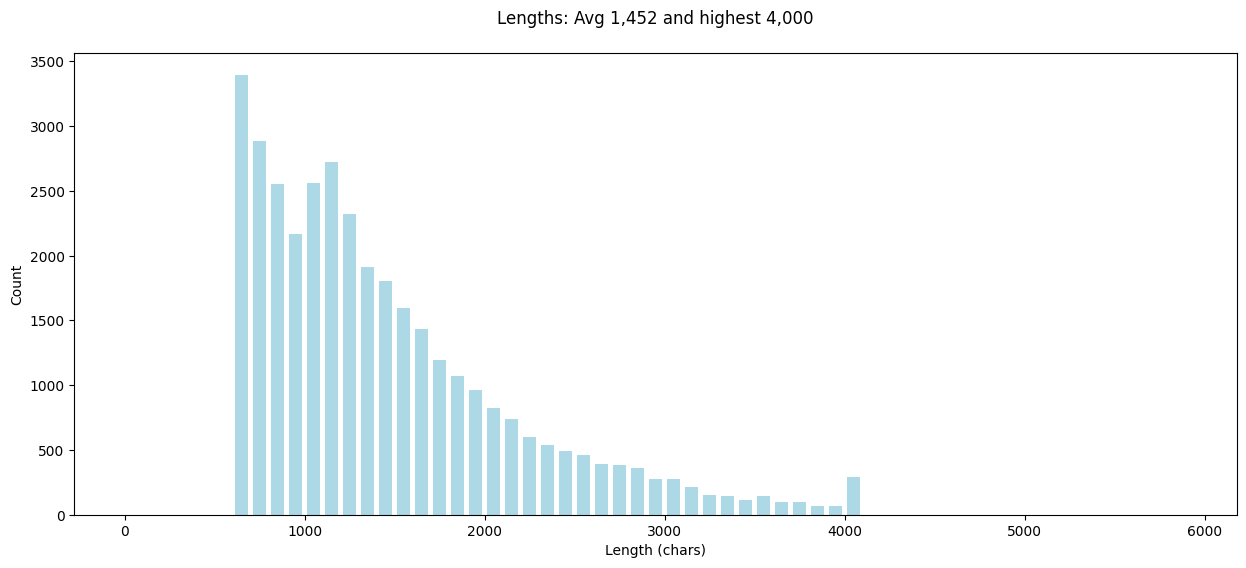

In [13]:
# Plot the distribution of lengths

plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

In [14]:
max_length = max(lengths)
max_length_item = items[lengths.index(max_length)]
print(max_length_item.full)


Polyester Dryer Vent Filters Replacement Part by Beaquicy Replacement for Better vent Indoor Dryer Vent Packs of 12
['✅【 AIR 】--- The polyester filters provide optimal air conditioning for your dryer and keep it away from polluted air. Because these parts will rate to trap fine lint and dust particles, protect your home from unwanted bacteria and other unfriendly dust particles and can be vacuumed clean or replaced when fully loaded with lint. so that the air in your room is cleaner than ever. While protecting your indoor quality, clothes can dry faster. It helps improve the indoor air quality.', '✅【HIGH-GRADE 】--- The package includes 12 x replacement polyester filters for bettervent.They are well-made from durable and high-grade polyester which can traps fine lint and dust particles, optimize the cleaning process and prolong lifetime. Each filter protects up to 5 dryer loads! For best results insert blue side facing towards dryer vent.', '✅【WIDE 】--- These polyester filters are desig

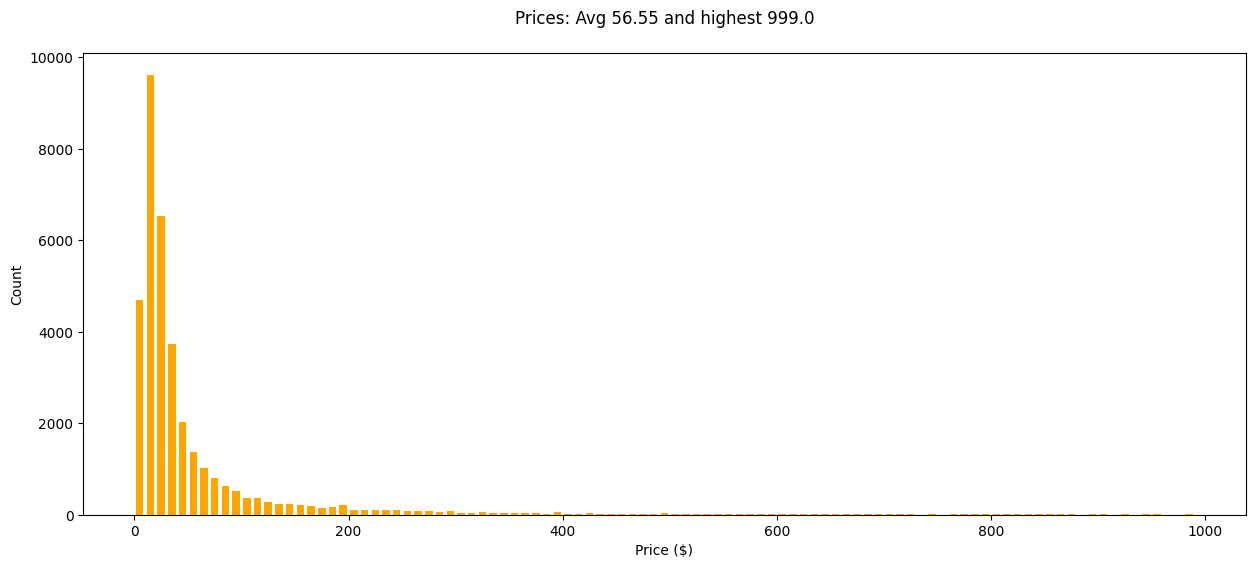

In [15]:
# Plot the distribution of prices
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.2f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="orange", bins=range(0, 1000, 10))
plt.show()

In [16]:
print(items[3].full)

MLGB Stainless Steel Brushed Pattern Dishwasher Magnet Cover Panel Decal Home Appliance Art, Stainless Steel Fridge Door Cover Decals Magnetic, Black, Mobile Magnetic 23" x 26"
['Stainless Steel Brushed Pattern Magnetic Dishwasher Panel Covers allow you to easily transform your kitchen as the seasons change. You can instantly get rid of outdated and/or mismatched appliances, will give your kitchen a refreshing look.', ':', 'Vinyl + rubber magnet', 'Occasion:', 'Magnet Dishwasher Cover Decor dishwasher covers and any metal device surface with magnetism.', '【Kitchen Dishwasher Covers SIZE】S - 23 W x 17 H inches; 58.5 W x 43 H cm;L - 23 W x 26 H inches; 58.5 W x 66 H cm;', 'Attention:', 'Just ensure that your dishwasher is magnetic before ordering the dishwasher cover magnet', 'Due to the inconsistent calibration of the monitor, the colors on the computer monitor may be slightly different.', 'Quality service:', 'If you have any questions or questions, please feel free to contact us and we

In [17]:
CHUNK_SIZE = 1000

cpu_count = os.cpu_count() or 1
WORKERS = max(cpu_count - 1, 1)


class ItemLoader:
    def __init__(self, category):
        self.category = category
        self.dataset = None

    def from_datapoint(self, datapoint):
        """
        Try to create an Item from this datapoint
        Return the Item if successful, or None if it shouldn't be included
        """
        return parse(datapoint, self.category)

    def from_chunk(self, chunk):
        """
        Create a list of Items from this chunk of elements from the Dataset
        """
        batch = [self.from_datapoint(datapoint) for datapoint in chunk]
        return [item for item in batch if item is not None]

    def chunk_generator(self):
        """
        Iterate over the Dataset, yielding chunks of datapoints at a time
        """
        size = len(self.dataset)
        for i in range(0, size, CHUNK_SIZE):
            yield self.dataset.select(range(i, min(i + CHUNK_SIZE, size)))

    def _run_pool(self, executor_cls, workers, chunk_count):
        results = []
        with executor_cls(max_workers=workers) as pool:
            for batch in tqdm(pool.map(self.from_chunk, self.chunk_generator()), total=chunk_count):
                results.extend(batch)
        return results

    def load_in_parallel(self, workers):
        """
        Use process workers in script environments and threads in notebooks.
        Automatically falls back to threads if a process pool crashes.
        """
        workers = max(int(workers), 1)
        chunk_count = (len(self.dataset) + CHUNK_SIZE - 1) // CHUNK_SIZE

        in_notebook = "ipykernel" in __import__("sys").modules
        use_processes = workers > 1 and not in_notebook

        if use_processes:
            try:
                return self._run_pool(ProcessPoolExecutor, workers, chunk_count)
            except BrokenProcessPool:
                print("Process pool crashed; retrying with threads.", flush=True)

        return self._run_pool(ThreadPoolExecutor, workers, chunk_count)

    def load(self, workers=WORKERS):
        """
        Load in this dataset; the workers parameter specifies how many processes
        should work on loading and scrubbing the data
        """
        start = datetime.now()
        print(f"Loading dataset {self.category}", flush=True)
        self.dataset = load_dataset(
            "McAuley-Lab/Amazon-Reviews-2023",
            f"raw_meta_{self.category}",
            split="full",
            trust_remote_code=True,
        )
        results = self.load_in_parallel(workers)
        finish = datetime.now()
        print(
            f"Completed {self.category} with {len(results):,} datapoints in {(finish - start).total_seconds() / 60:.1f} mins",
            flush=True,
        )
        return results


In [18]:
loader = ItemLoader("Appliances")
items = loader.load()

Loading dataset Appliances


  0%|          | 0/95 [00:00<?, ?it/s]

Completed Appliances with 35,307 datapoints in 0.7 mins


In [19]:

dataset_names = [
    "Automotive",
    "Electronics",
    "Office_Products",
    "Tools_and_Home_Improvement",
    "Cell_Phones_and_Accessories",
    "Toys_and_Games",
    "Appliances",
    "Musical_Instruments",
]

In [20]:
items = []
for dataset_name in dataset_names:
    loader = ItemLoader(dataset_name)
    items.extend(loader.load())

Loading dataset Automotive


  0%|          | 0/2004 [00:00<?, ?it/s]

Completed Automotive with 974,469 datapoints in 13.6 mins
Loading dataset Electronics


  0%|          | 0/1611 [00:00<?, ?it/s]

Completed Electronics with 464,024 datapoints in 9.6 mins
Loading dataset Office_Products


...

Completed Toys_and_Games with 347,657 datapoints in 5.7 mins
Loading dataset Appliances


  0%|          | 0/95 [00:00<?, ?it/s]

Completed Appliances with 35,307 datapoints in 0.6 mins
Loading dataset Musical_Instruments


  0%|          | 0/214 [00:00<?, ?it/s]

Completed Musical_Instruments with 68,855 datapoints in 1.2 mins


# Removing duplicates

In [21]:
random.seed(42)
random.shuffle(items)

seen = set()
items = [x for x in tqdm(items) if not (x.title in seen or seen.add(x.title))]

seen = set()
items = [x for x in tqdm(items) if not (x.full in seen or seen.add(x.full))]

del seen
print(f"After deduplication, we have {len(items):,} items")

  0%|          | 0/2933577 [00:00<?, ?it/s]

  0%|          | 0/2889429 [00:00<?, ?it/s]

After deduplication, we have 2,887,890 items


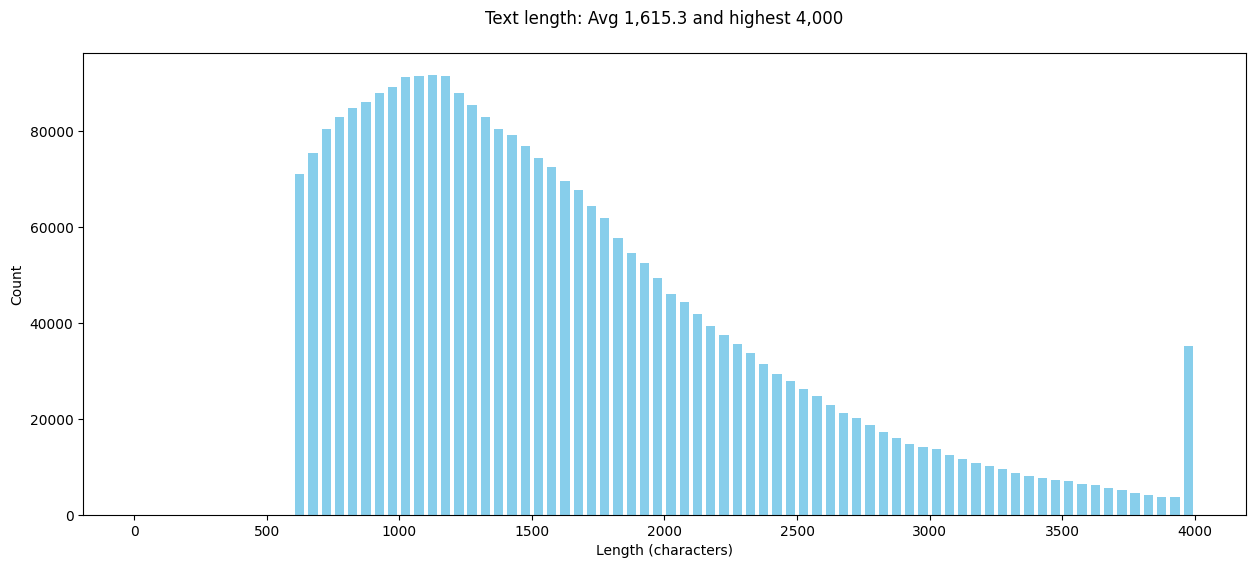

In [22]:
lengths = [len(item.full) for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Text length: Avg {sum(lengths)/len(lengths):,.1f} and highest {max(lengths):,}\n")
plt.xlabel('Length (characters)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="skyblue", bins=range(0, 4050, 50))
plt.show()

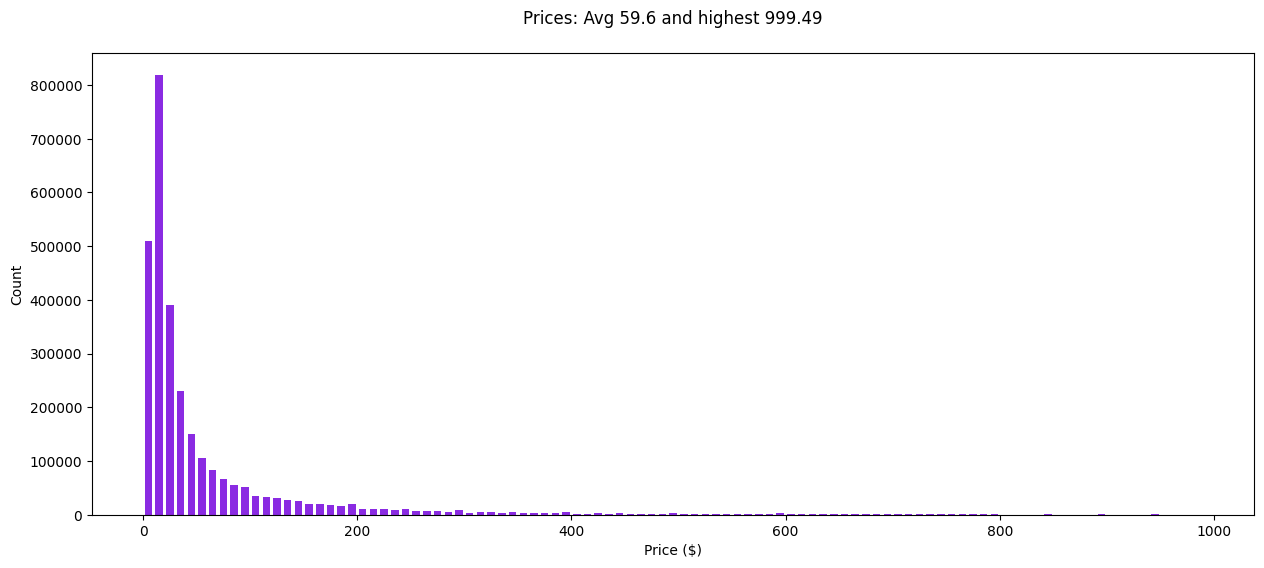

In [23]:
# Plot the distribution of prices

prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

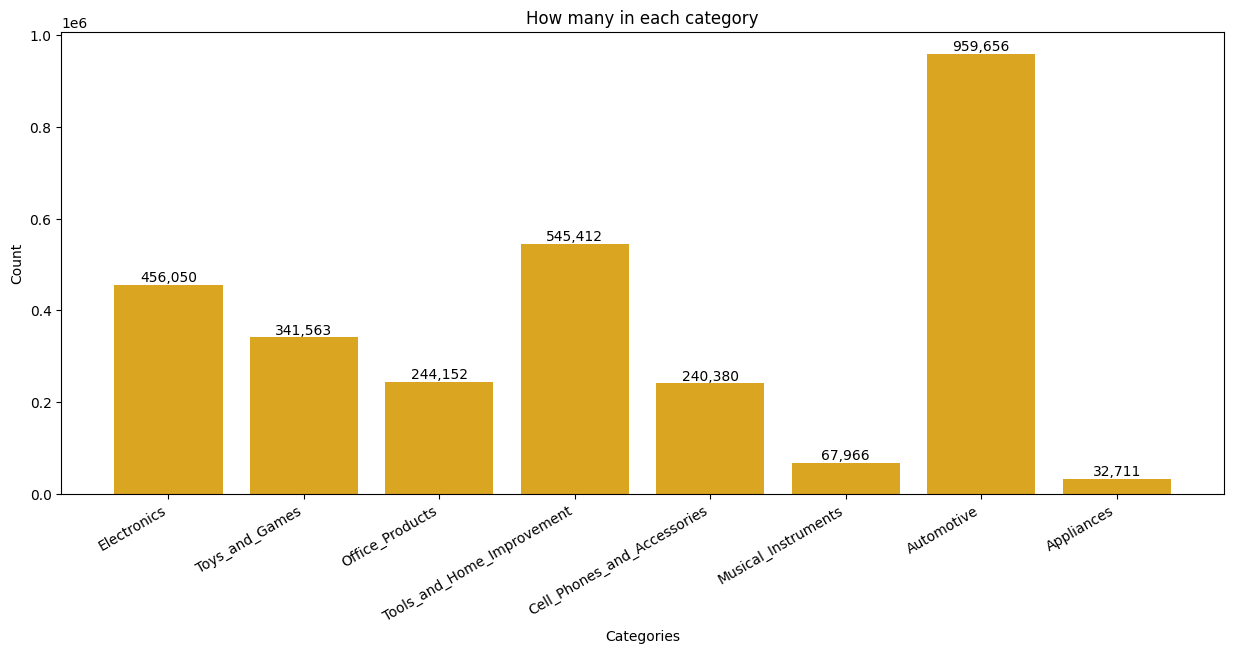

In [25]:
from collections import Counter
category_counts = Counter([item.category for item in items])

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')

for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()

In [26]:
np.random.seed(42)

SIZE = 820_000

prices = np.array([it.price for it in items], dtype=float)
categories = np.array([it.category for it in items])
p = (prices - prices.min()) / (prices.max() - prices.min() + 1e-9)

w = p**2
w[categories == "Tools_and_Home_Improvement"] *= 0.5
w[categories == "Automotive"] *= 0.05

w = w / w.sum()
idx = np.random.choice(len(items), size=SIZE, replace=False, p=w)
sample = [items[i] for i in idx]


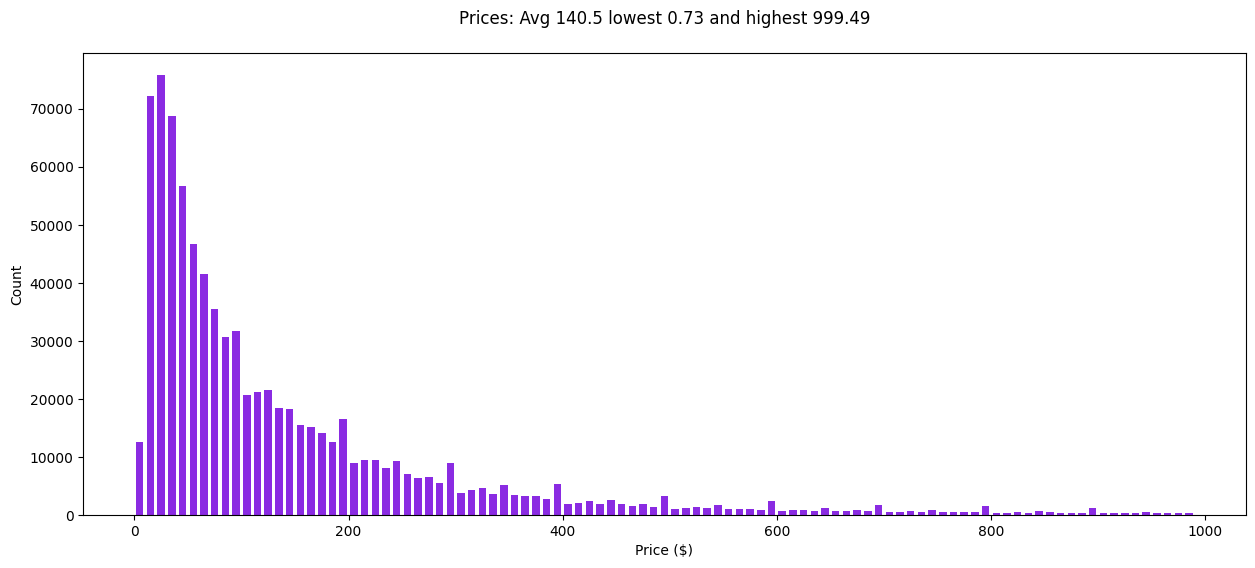

In [27]:
prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} lowest {min(prices):,} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

In [28]:
# Just for good measure, let's shuffle the sample again for the final dataset

random.seed(42)
random.shuffle(sample)


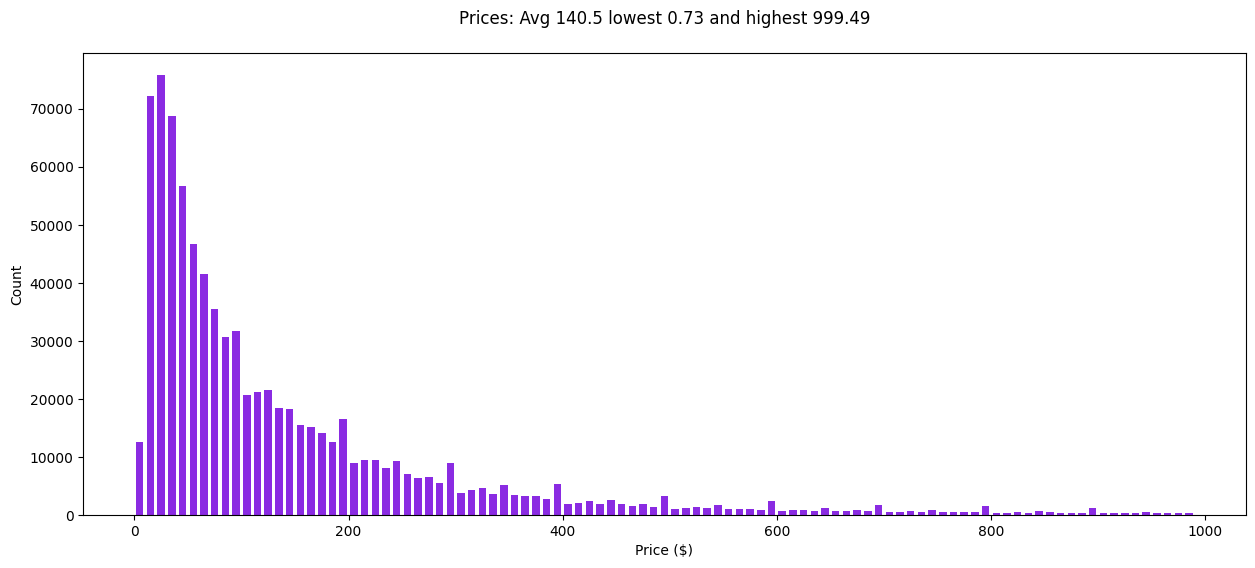

In [29]:
prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} lowest {min(prices):,} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

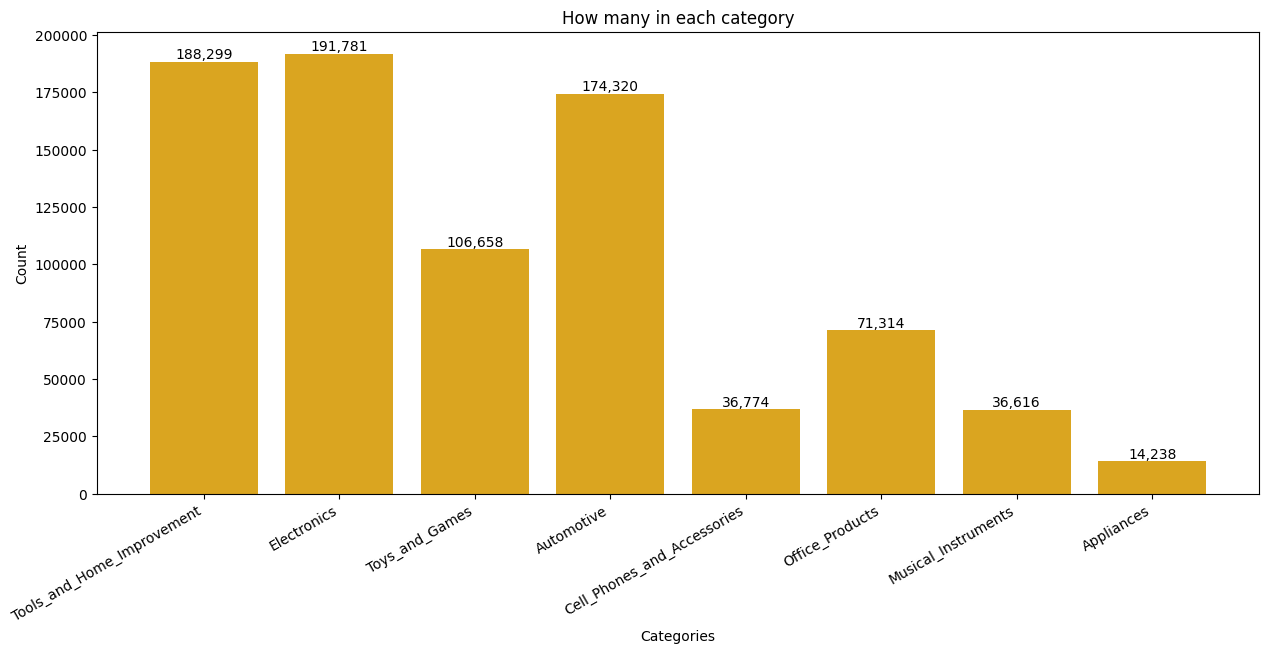

In [30]:
from collections import Counter
category_counts = Counter([item.category for item in sample])

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# Bar chart by category
plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')

plt.xticks(rotation=30, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

# Display the chart
plt.show()

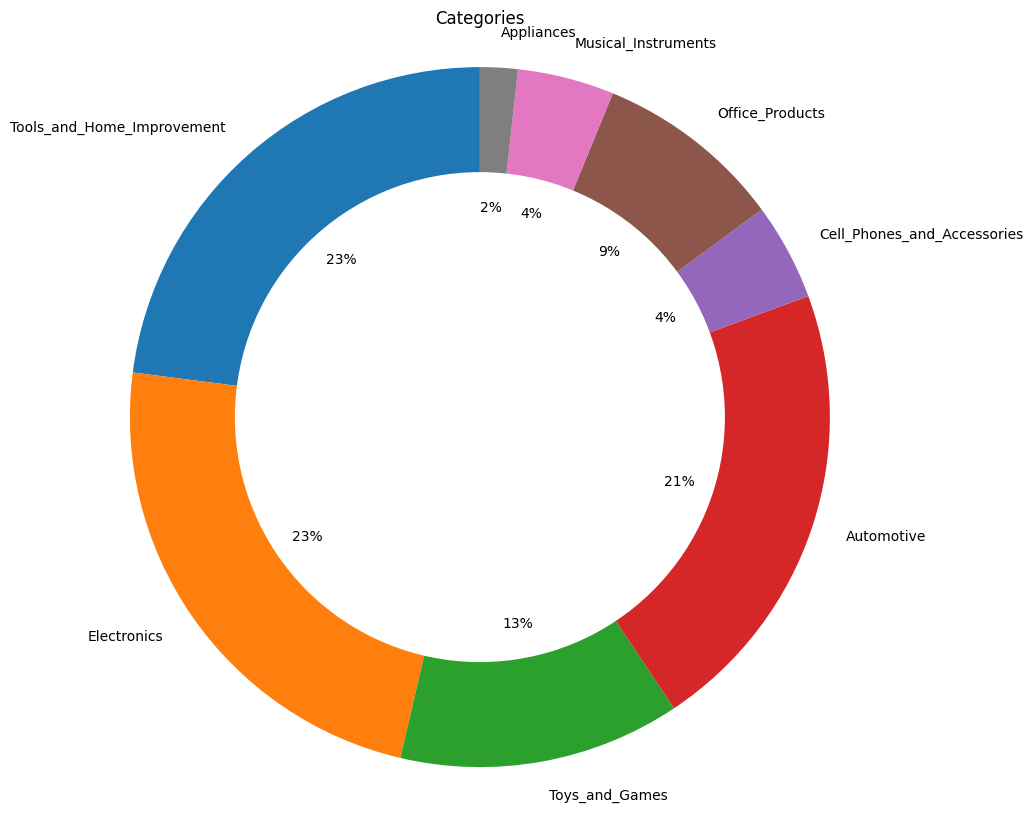

In [31]:
# Automotive still in the lead, but improved somewhat
# For another perspective, let's look at a pie

plt.figure(figsize=(12, 10))
plt.pie(counts, labels=categories, autopct='%1.0f%%', startangle=90)

# Add a circle at the center to create a donut chart (optional)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Categories')

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')  

plt.show()

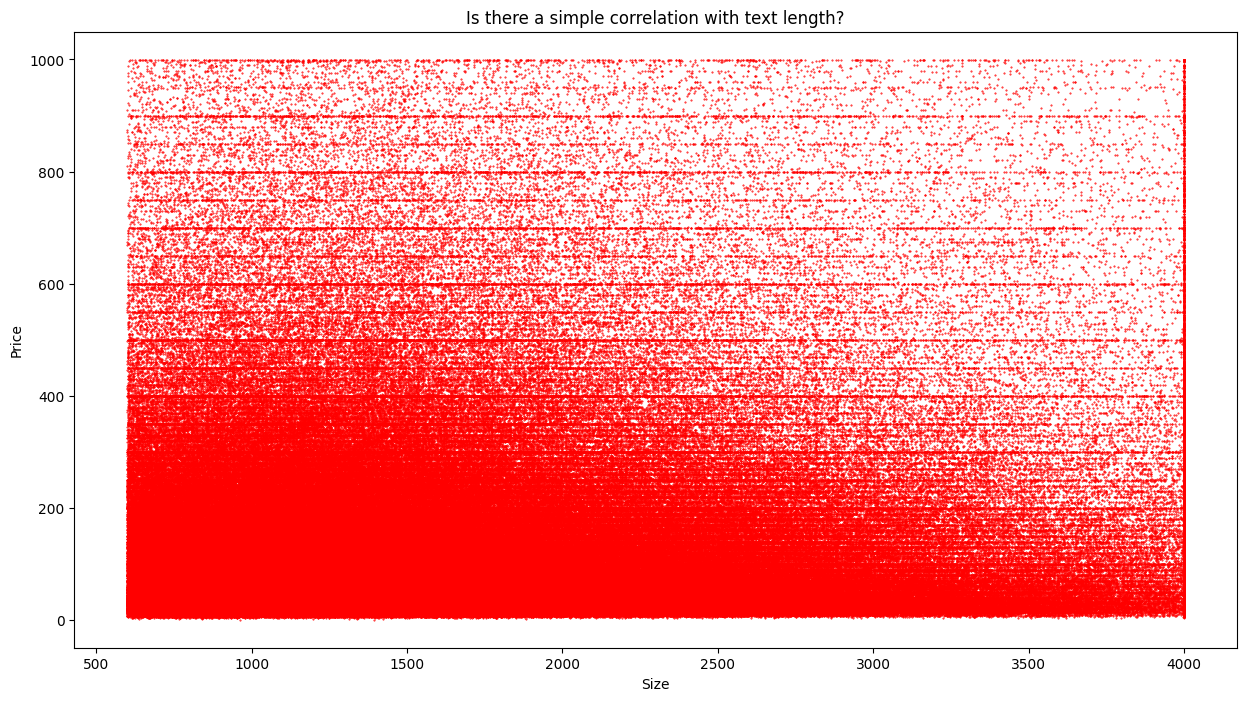

In [32]:
# How does the price vary with the character count?

sizes = [len(item.full) for item in sample]
prices = [item.price for item in sample]

# Create the scatter plot
plt.figure(figsize=(15, 8))
plt.scatter(sizes, prices, s=0.2, color="red")

# Add labels and title
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Is there a simple correlation with text length?')

# Display the plot
plt.show()

In [ ]:
# How does the price vary with the weight?

ounces = [item.weight for item in sample]
prices = [item.price for item in sample]

# Create the scatter plot
plt.figure(figsize=(15, 8))
plt.scatter(ounces, prices, s=0.2, color="darkorange")

# Add labels and title
plt.xlabel('Weight (ounces)')
plt.ylabel('Price')
plt.xlim(0, 400)
plt.title('Is there a simple correlation with weight?')

# Display the plot
plt.show()

## Pushing the dataset to hugging face

In [37]:
username = "TumeloKonaite"
#full = f"{username}/items_raw_full"
lite = f"{username}/items_raw_lite"



train_lite = sample[:20_000]
val_lite = sample[:1_000]
test_lite = sample[:1_000]

Item.push_to_hub(lite, train_lite, val_lite, test_lite)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/20 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            